<a href="https://colab.research.google.com/github/indra1236/indra/blob/main/Pengolahan_Citra_Digital_pertemuan_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

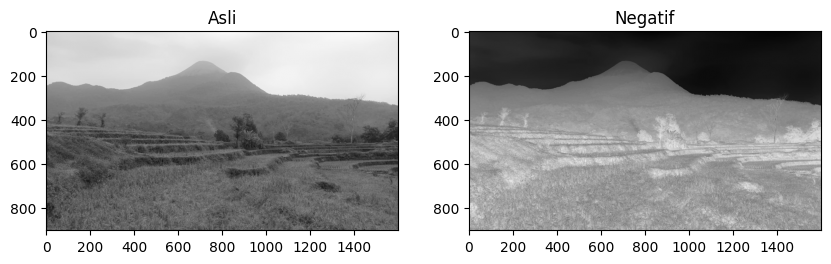

In [59]:
import cv2
import numpy as np # Gunakan 'as', bukan 'sebagai'
import matplotlib.pyplot as plt # Gunakan 'as', bukan 'sebagai'

# Membaca gambar dalam mode grayscale (0)
# Pastikan file 'Gambar.jpg' ada di folder yang sama dengan script ini
img = cv2.imread('Gambar.jpg', 0)

# Jika gambar gagal dimuat, kita beri proteksi sederhana
if img is None:
    print("Error: Gambar tidak ditemukan!")
else:
    # Operasi negatif: s = L - 1 - r
    negatif = 255 - img

    # Menampilkan hasil
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Asli")
    plt.imshow(img, cmap='gray') # Gunakan petik lurus '...' bukan petik lengkung ‘...’

    plt.subplot(1, 2, 2)
    plt.title("Negatif")
    plt.imshow(negatif, cmap='gray')

    plt.show()

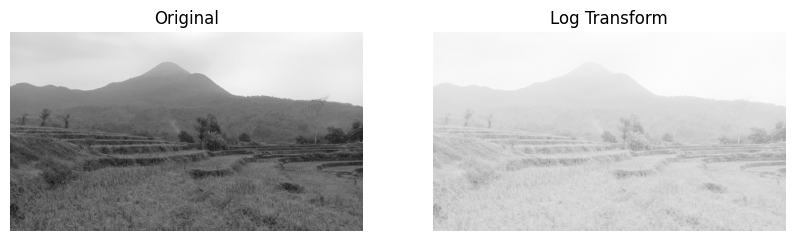

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Pastikan file ada sebelum membaca
file_path = 'Gambar.jpg'
if not os.path.exists(file_path):
    print(f"Error: File '{file_path}' tidak ditemukan di folder ini!")
else:
    img = cv2.imread(file_path, 0)

    # 2. Konversi ke float32 untuk perhitungan presisi
    img_float = np.float32(img)

    # 3. Operasi Log Transform
    # Rumus: s = c * log(1 + r)
    # Kita gunakan np.max untuk mencari nilai maksimal agar hasil akhir tetap di rentang 0-255
    max_pixel_value = np.max(img_float)

    # Tambahkan angka sangat kecil (1e-5) agar tidak terjadi pembagian dengan nol jika max_pixel adalah 0
    c = 255 / np.log(1 + max_pixel_value + 1e-5)

    log_transform = c * np.log(1 + img_float)

    # 4. Konversi kembali ke uint8 (8-bit)
    log_transform = np.uint8(log_transform)

    # Menampilkan hasil
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')
    plt.axis('off') # Menghilangkan angka koordinat agar lebih rapi

    plt.subplot(1, 2, 2)
    plt.title("Log Transform")
    plt.imshow(log_transform, cmap='gray')
    plt.axis('off')

    plt.show()

File 'gambar.jpg' tidak ditemukan! Silakan upload file ke sidebar kiri Colab.


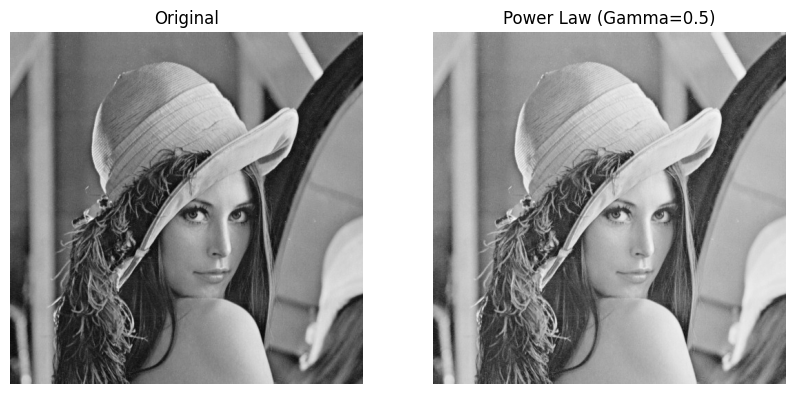

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Cek keberadaan file di Google Colab
file_name = 'gambar.jpg'

if not os.path.exists(file_name):
    print(f"File '{file_name}' tidak ditemukan! Silakan upload file ke sidebar kiri Colab.")
    # Opsional: Gunakan gambar sampel dari internet agar kode tetap jalan
    os.system(f"curl -o {file_name} https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg")

# 2. Membaca gambar dalam grayscale
img = cv2.imread(file_name, 0)

if img is None:
    print("Gagal memuat gambar. Periksa format file Anda.")
else:
    # Parameter Gamma
    # Gamma < 1: Memperterang (Brighten)
    # Gamma > 1: Mempergelap (Darken)
    gamma = 0.5
    c = 1

    # 3. Normalisasi & Operasi Power-Law (Gamma Correction)
    # Rumus: s = c * r^gamma
    img_norm = img / 255.0  # Konversi ke rentang [0, 1]

    # Melakukan transformasi
    power_transformed = c * np.power(img_norm, gamma)

    # 4. Skala kembali ke rentang [0, 255] dan konversi ke uint8
    power_final = np.uint8(np.clip(power_transformed * 255, 0, 255))

    # 5. Menampilkan hasil
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Power Law (Gamma={gamma})")
    plt.imshow(power_final, cmap='gray')
    plt.axis('off')

    plt.show()